In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [2]:
df = pd.read_csv("concrete_data.csv")
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
df.shape

(1030, 9)

In [4]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [ ]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
X = df.drop("Strength",axis=1)
y = df["Strength"]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.6275531792314848

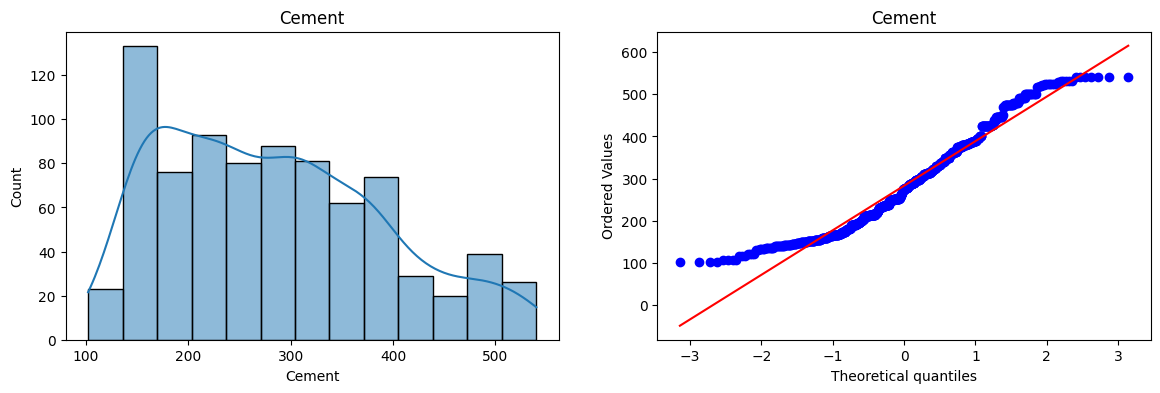

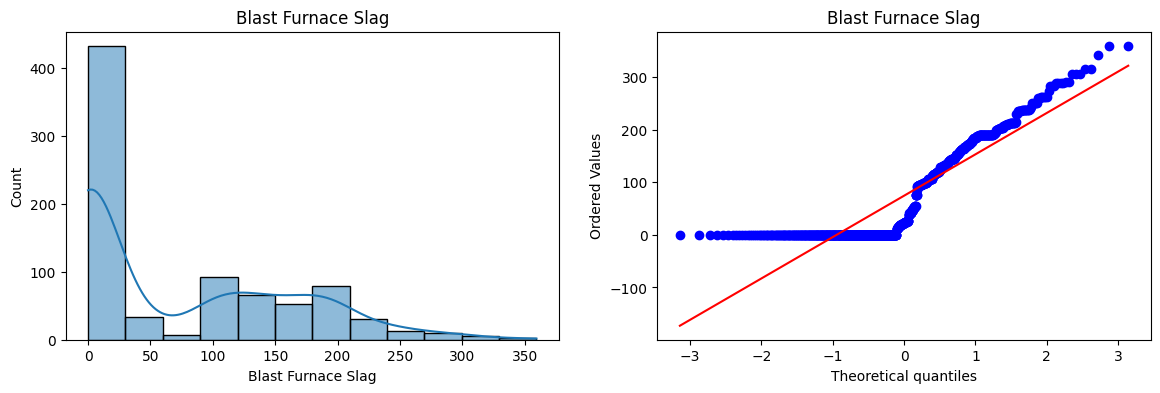

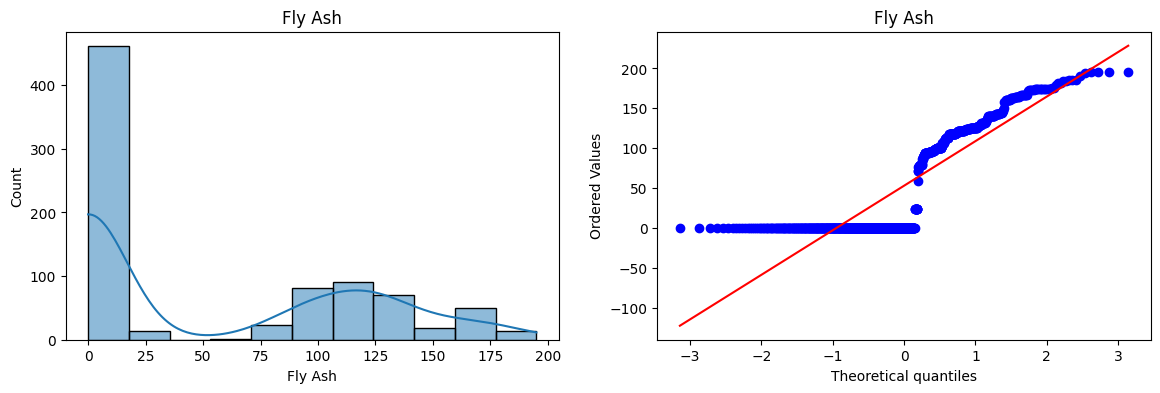

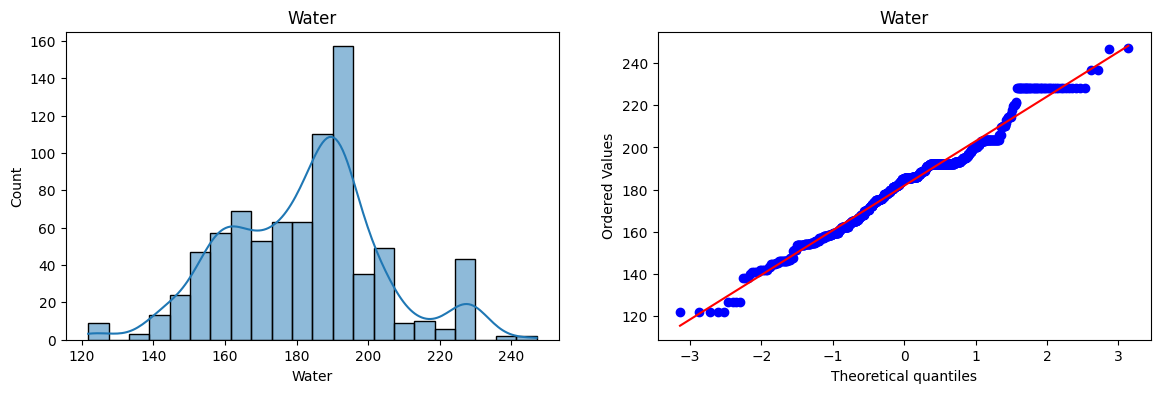

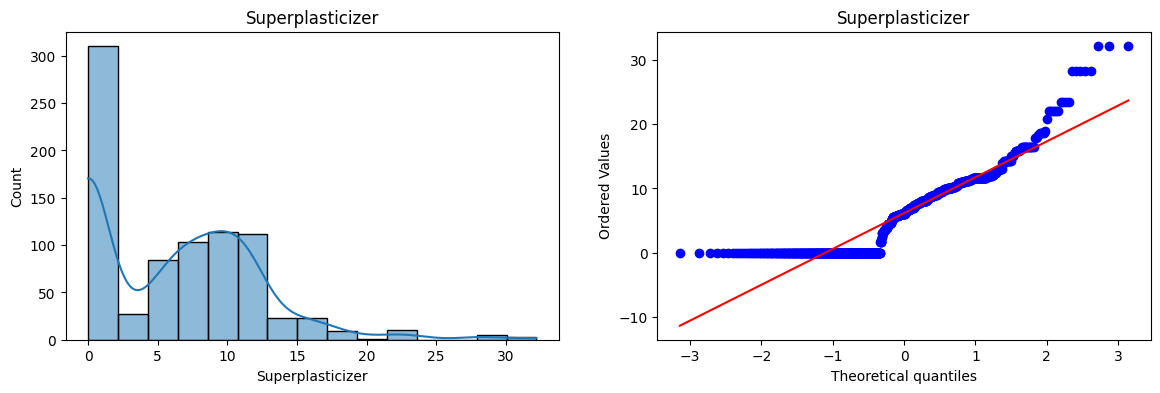

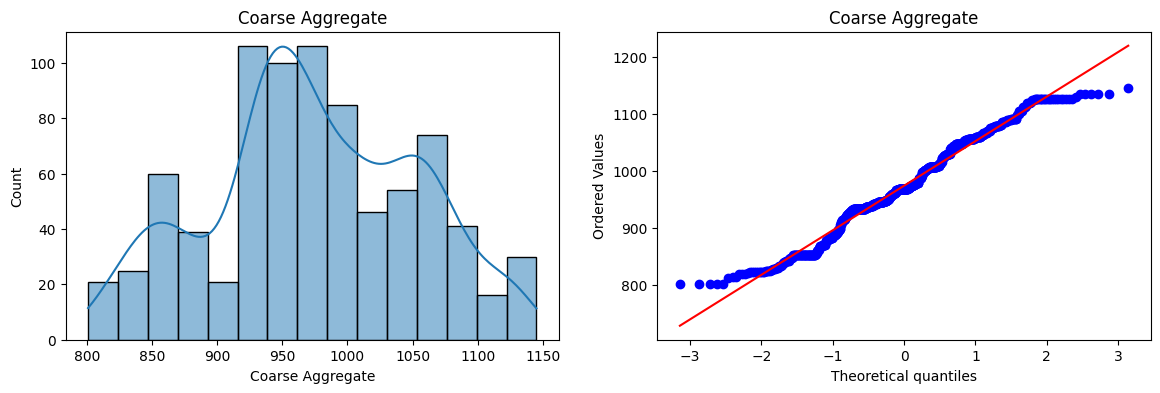

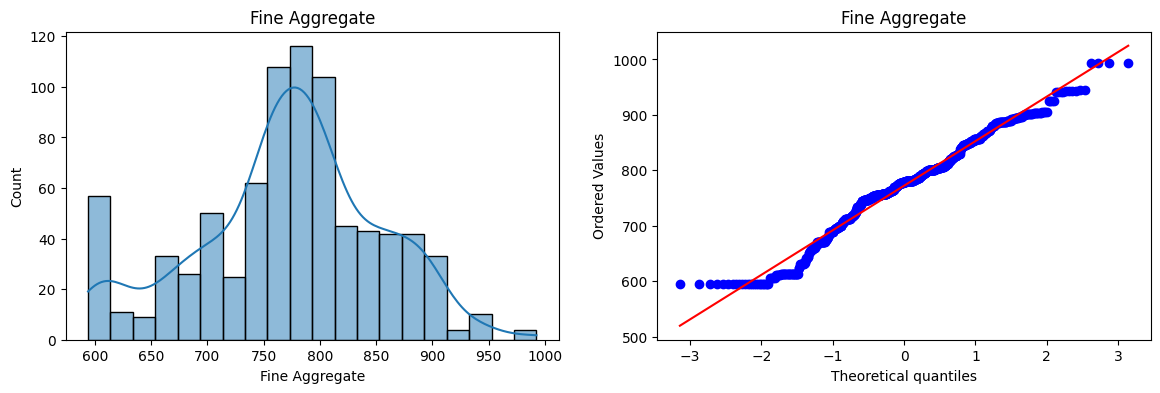

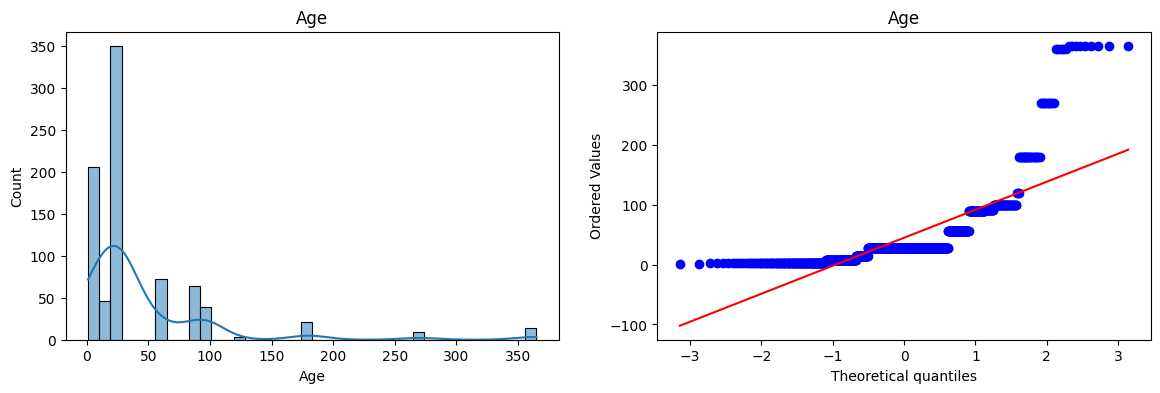

In [12]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True)
    plt.title(col)


    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm",plot=plt)
    plt.title(col)
    plt.show()

## Power Transformer

In [13]:
pt = PowerTransformer(method='box-cox')


X_train_transformed = pt.fit_transform(X_train+0.00001)
X_test_transformed = pt.transform(X_test+0.00001)

pd.DataFrame({'col':X_train.columns,'box-cox_lambdas':pt.lambdas_})

,col,box-cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.027842
2,Fly Ash,-0.044554
3,Water,0.772682
4,Superplasticizer,0.113892
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066630


In [14]:
lr = LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred2 = lr.predict(X_test_transformed)
r2_score(y_test,y_pred2)

0.8054599366002649

In [15]:
# using cross val score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537941434357)

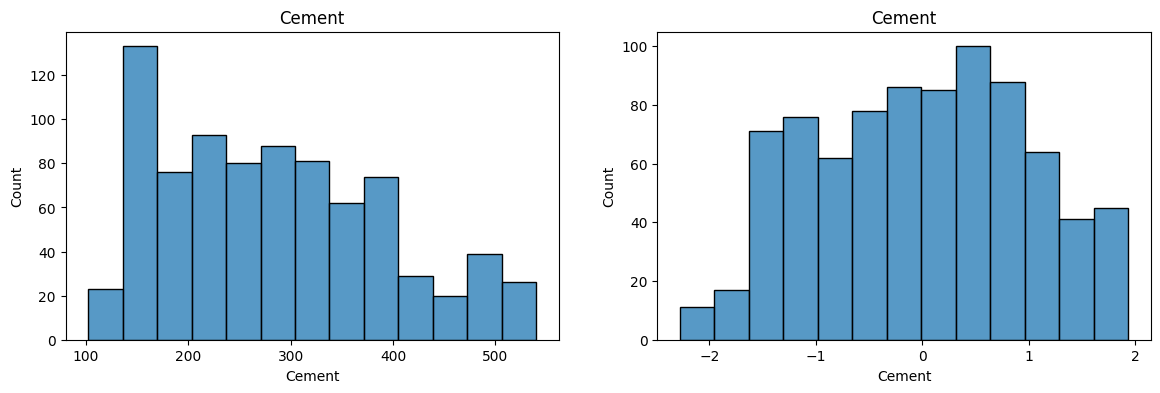

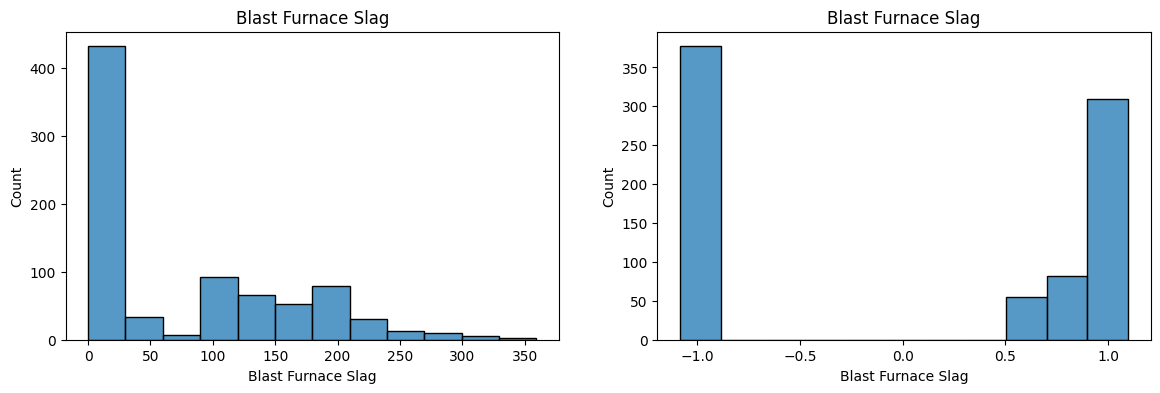

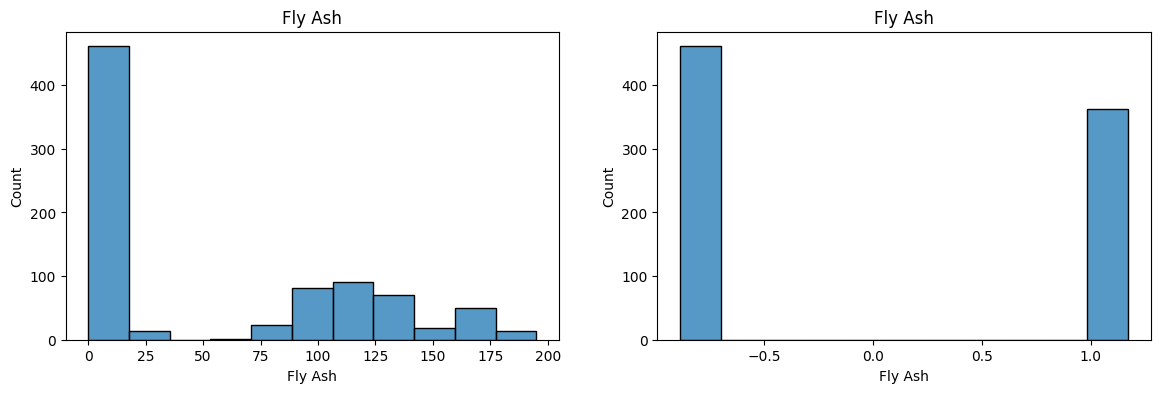

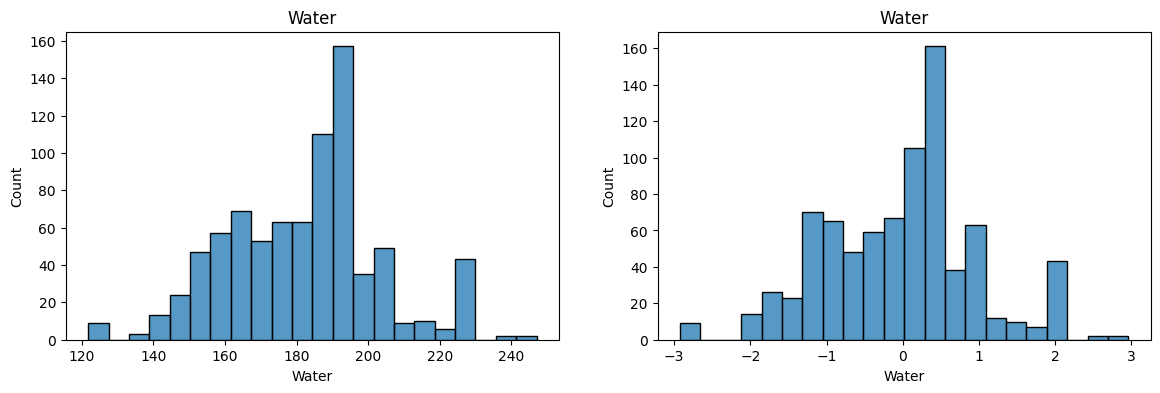

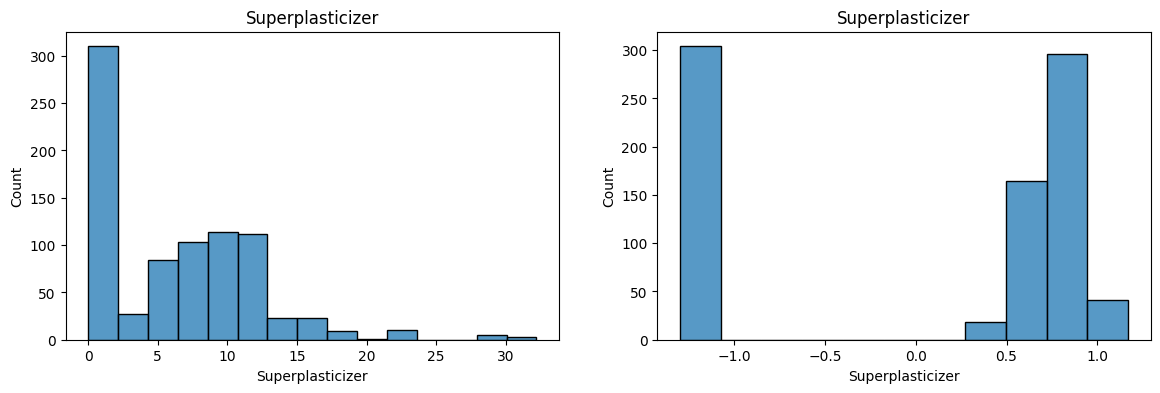

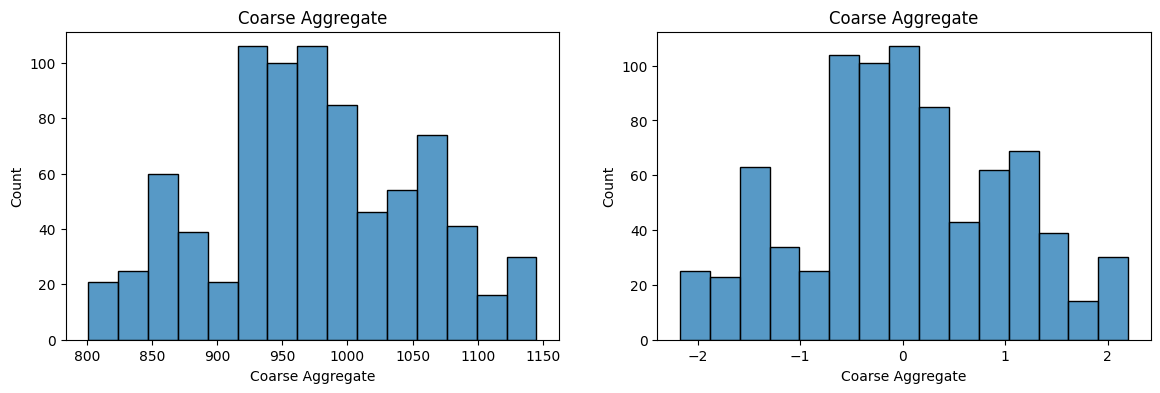

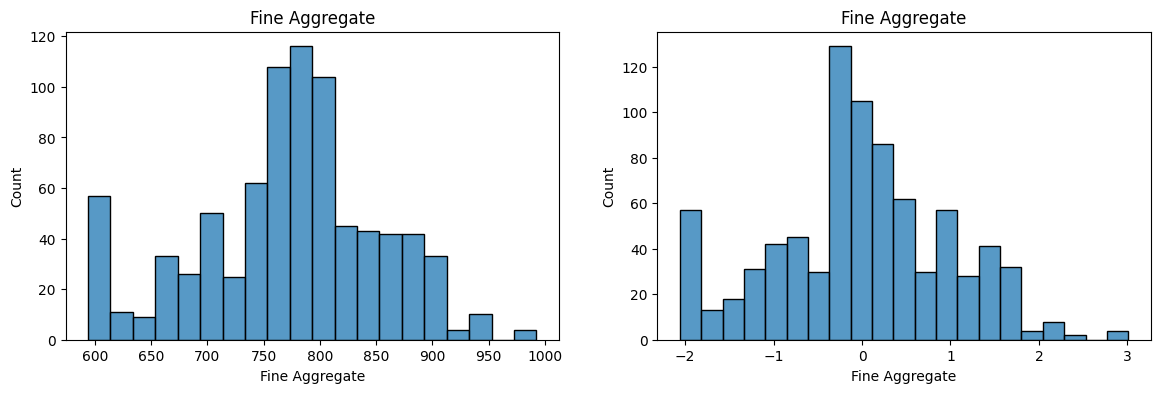

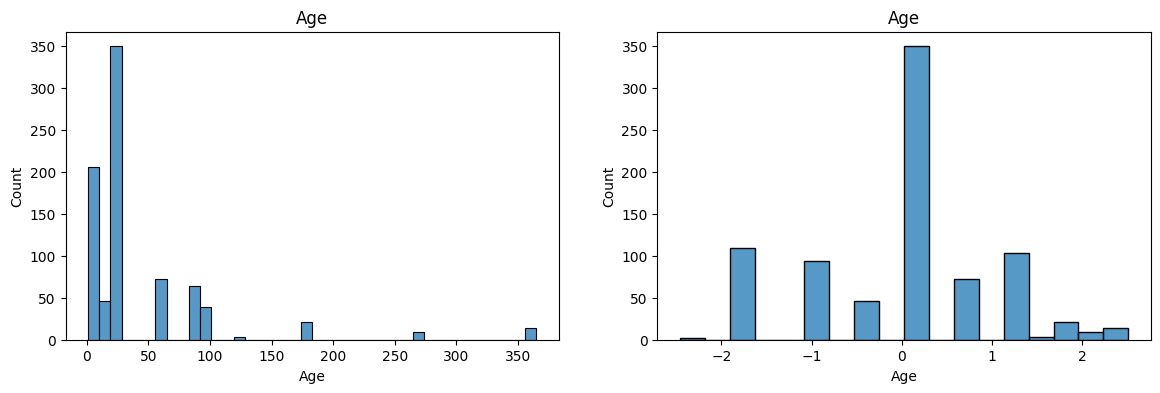

In [17]:
# Before and after transformation for Box-Cox plot


X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)
for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col])
    plt.title(col)


    plt.subplot(122)
    sns.histplot(X_train_transformed[col])
    plt.title(col)
    plt.show()


   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Strength  
0            1040.0           676.0   28     79.99  
1            1055.0           676.0   28     61.89  
2             932.0           594.0  270     40.27  
3             932.0           594.0  365     41.05  
4             978.4           825.5  360     44.30  
Baseline R2 score: 0.6275531792314848


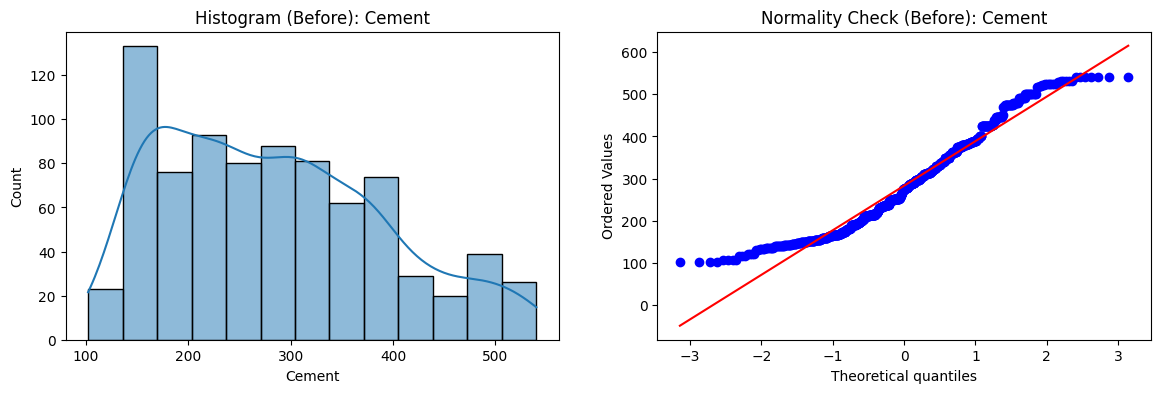

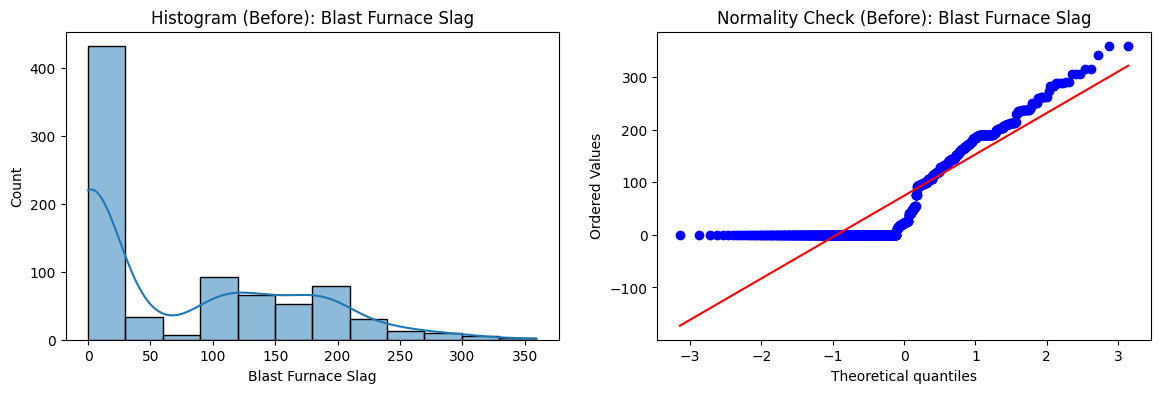

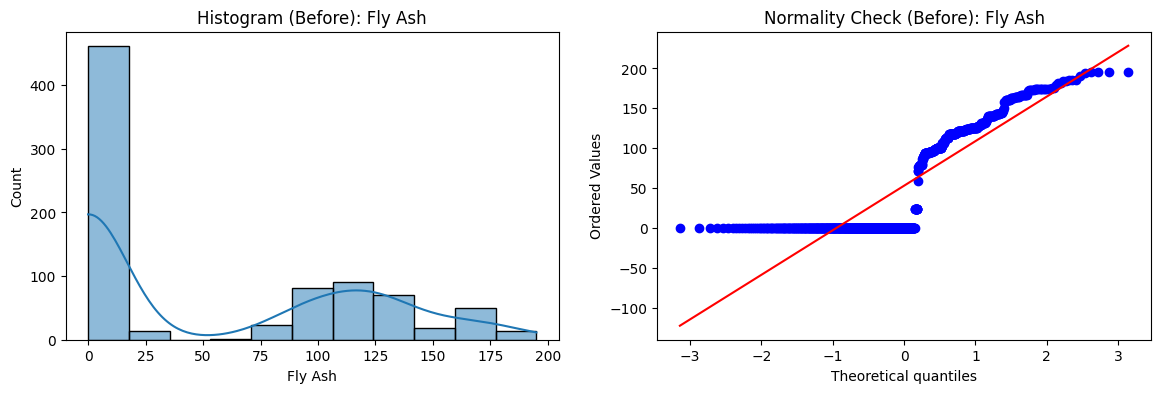

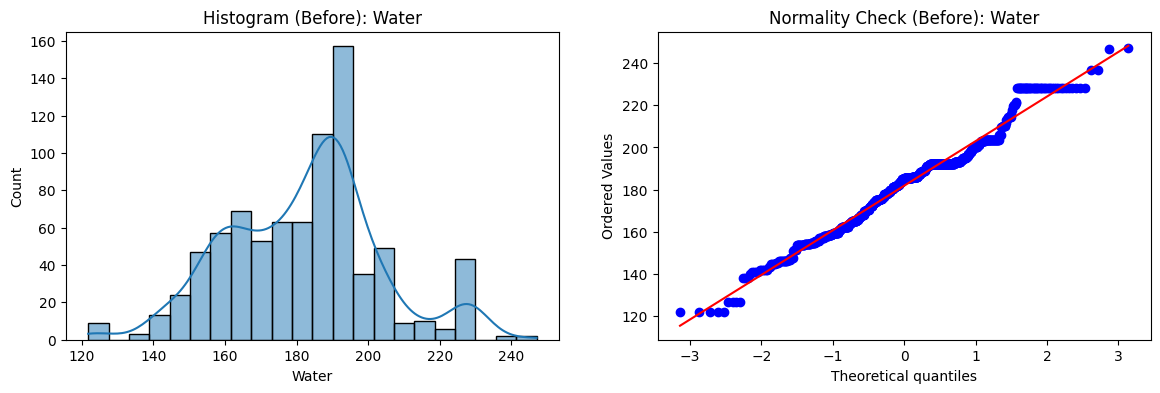

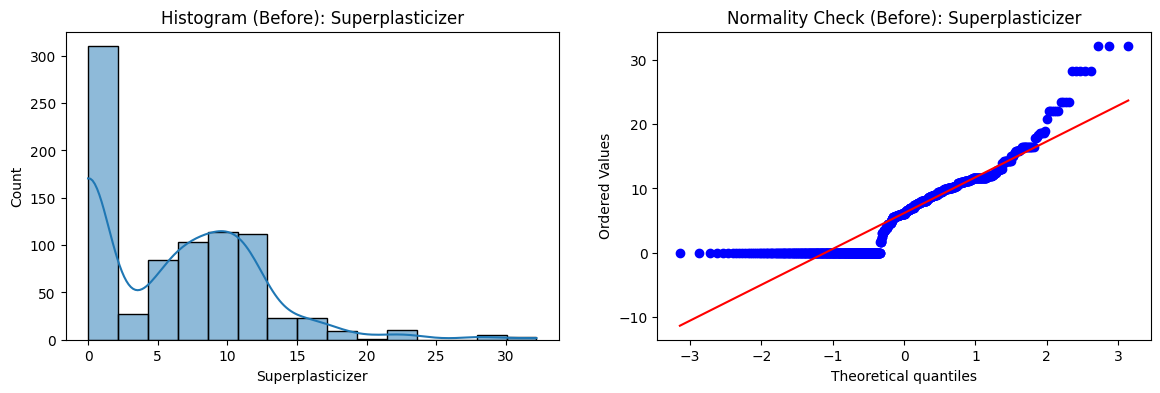

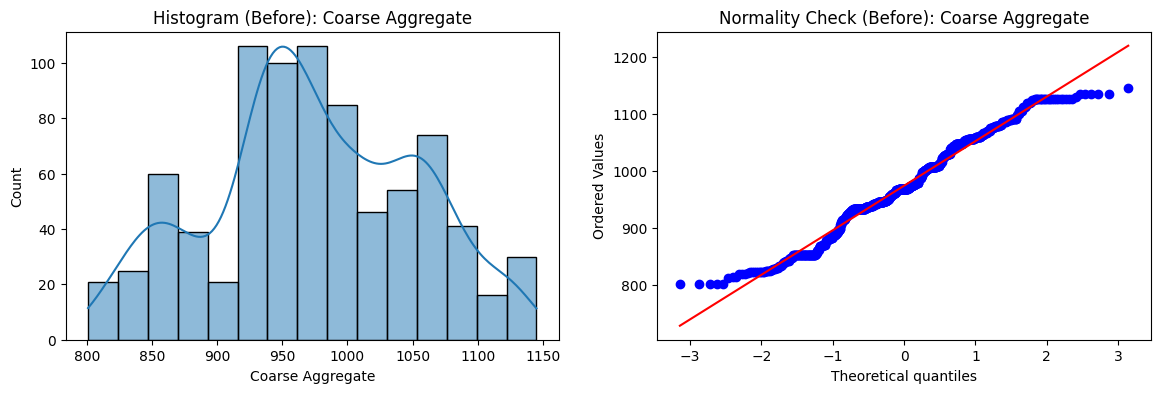

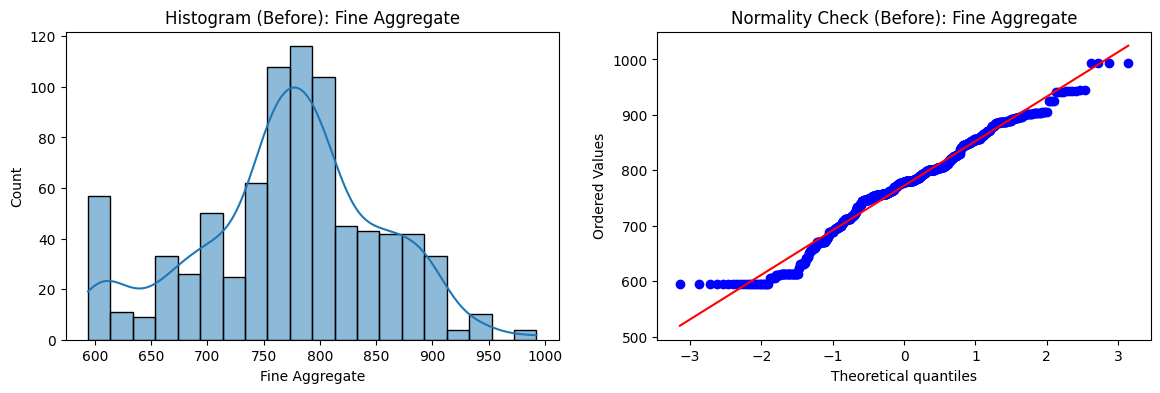

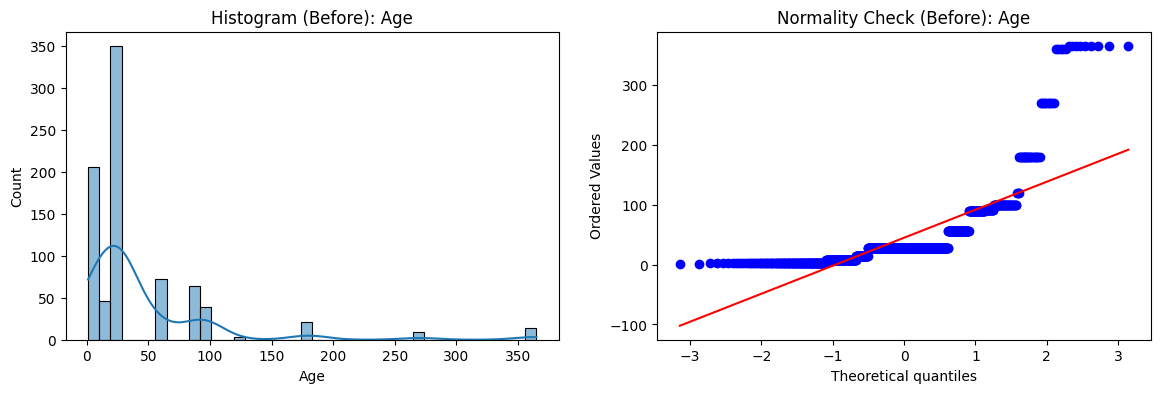

              Feature  Box-Cox λ
0              Cement   0.177025
1  Blast Furnace Slag   0.027842
2             Fly Ash  -0.044554
3               Water   0.772682
4    Superplasticizer   0.113892
5    Coarse Aggregate   1.129813
6      Fine Aggregate   1.782018
7                 Age   0.066630


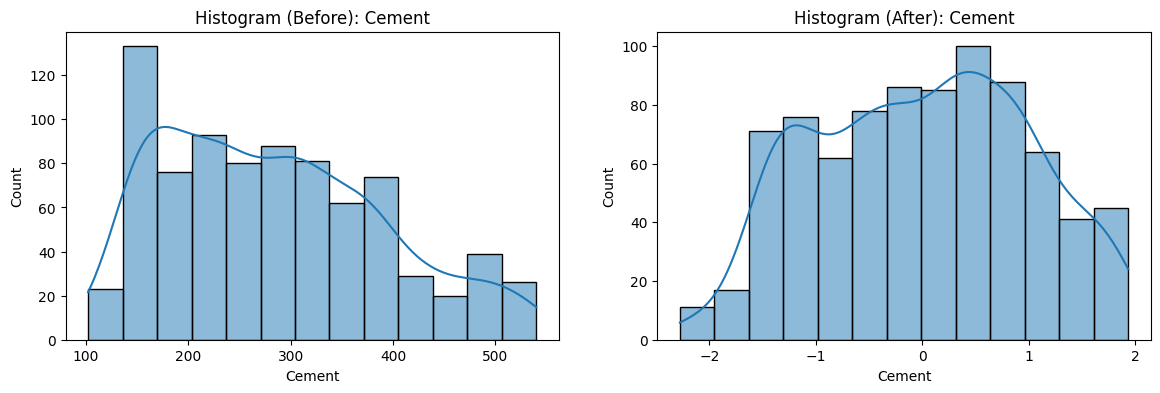

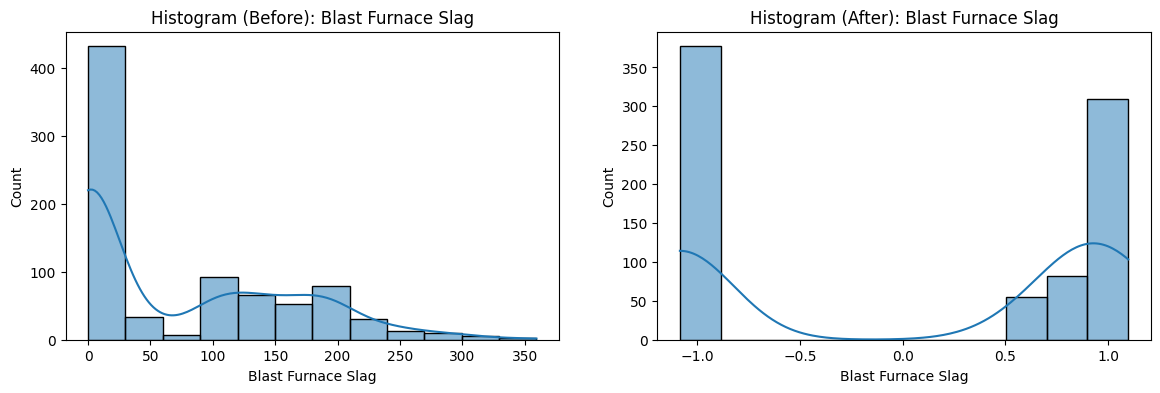

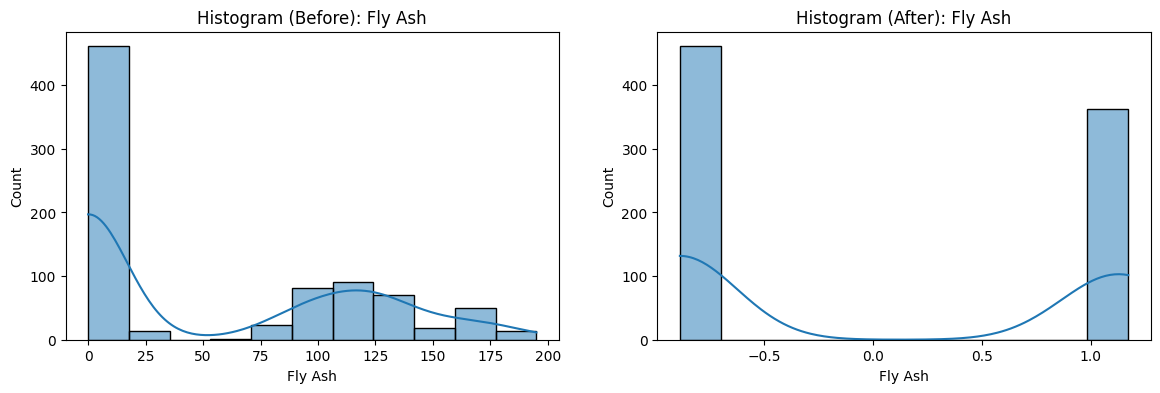

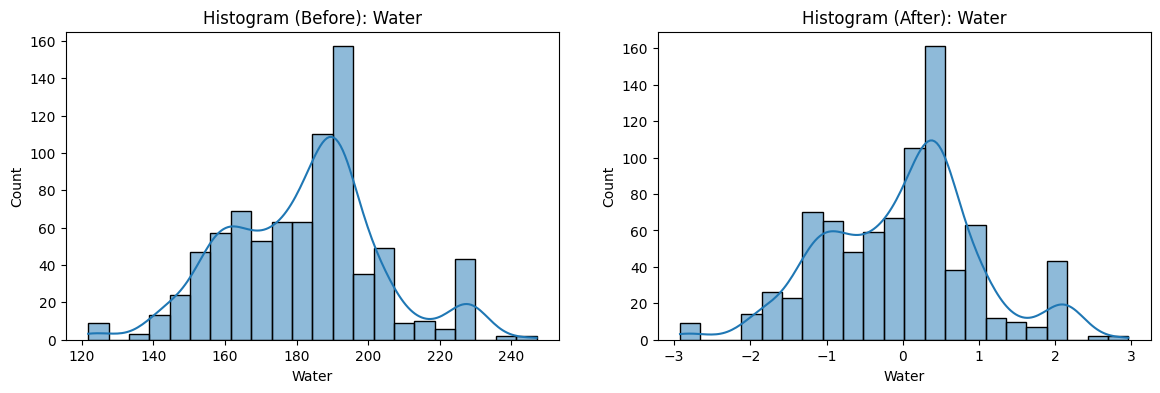

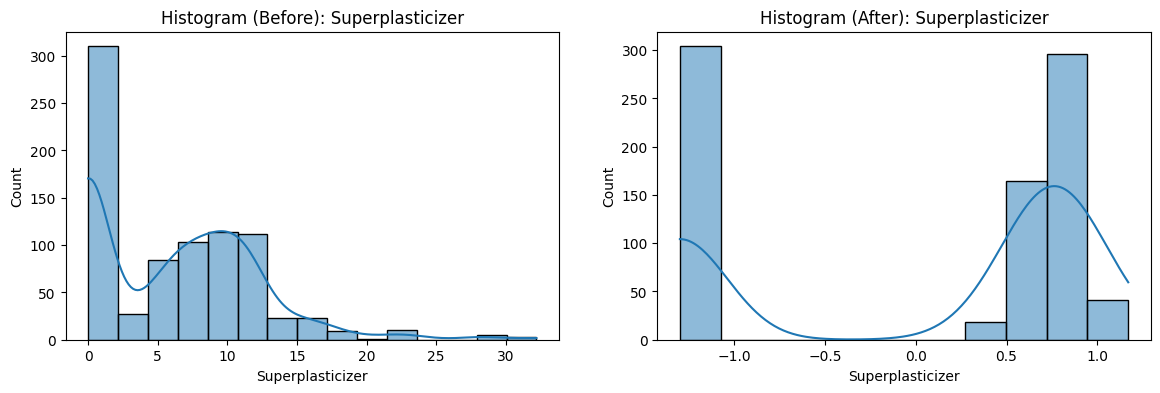

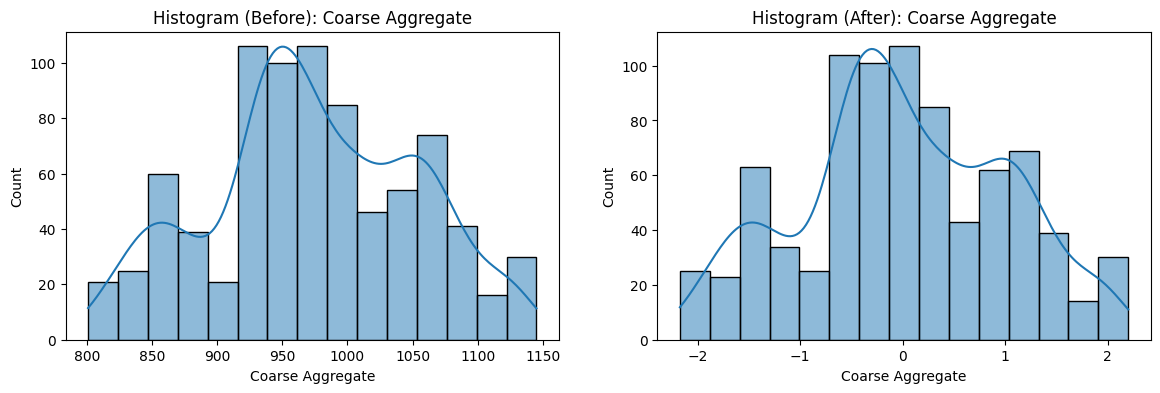

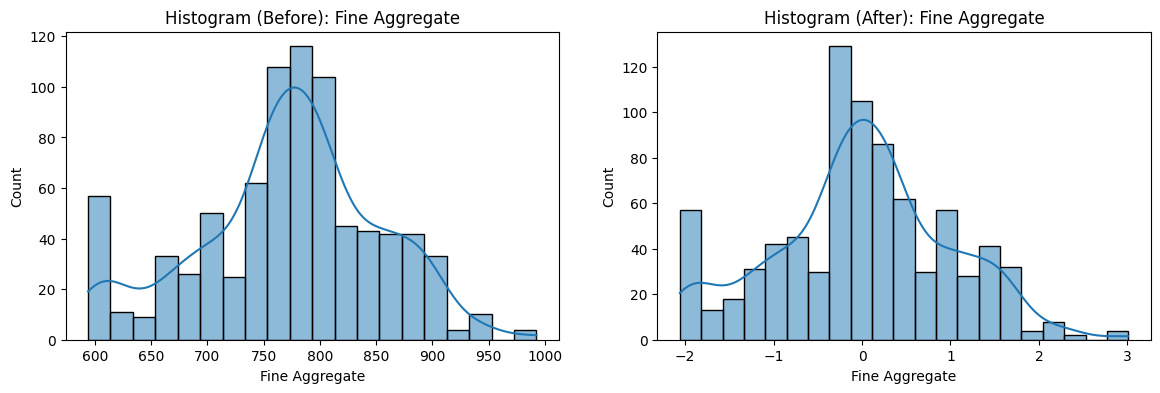

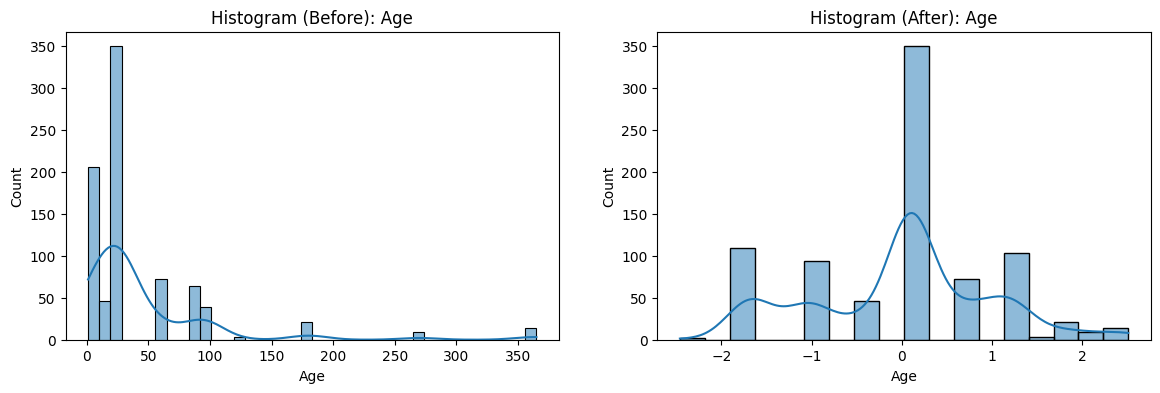

c:\conda_envs\eda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


R2 score after Box-Cox: 0.8054599366002649
Cross-validated R2 score: 0.6668489649183531


In [ ]:
# -------------------------------
# 1. Import libraries
# -------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

# -------------------------------
# 2. Load dataset
# -------------------------------
df = pd.read_csv("concrete_data.csv")
print(df.head())

# -------------------------------
# 3. Split features and target
# -------------------------------
X = df.drop("Strength", axis=1)   # Features
y = df["Strength"]                # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Baseline Linear Regression (without transformation)
# -------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Baseline R2 score:", r2_score(y_test, y_pred))

# -------------------------------
# 5. Visualize distributions before transformation
# -------------------------------
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    
    # Histogram
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Histogram (Before): {col}")
    
    # Probability plot (check normality)
    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f"Normality Check (Before): {col}")
    
    plt.show()

# -------------------------------
# 6. Apply Box-Cox Transformation
# -------------------------------
# Box-Cox requires strictly positive values, so add a tiny constant
pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train + 1e-5)
X_test_transformed = pt.transform(X_test + 1e-5)

# Convert back to DataFrame for readability
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)

# Show the lambda values (Box-Cox parameters for each feature)
print(pd.DataFrame({'Feature': X_train.columns, 'Box-Cox λ': pt.lambdas_}))

# -------------------------------
# 7. Visualize distributions after transformation
# -------------------------------
for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    
    # Histogram before
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Histogram (Before): {col}")
    
    # Histogram after
    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(f"Histogram (After): {col}")
    
    plt.show()

# -------------------------------
# 8. Linear Regression (after transformation)
# -------------------------------
lr = LinearRegression()
lr.fit(X_train_transformed, y_train)
y_pred2 = lr.predict(X_test_transformed)

print("R2 score after Box-Cox:", r2_score(y_test, y_pred2))

# -------------------------------
# 9. Cross-validation with transformed data
# -------------------------------
X_transformed = pt.fit_transform(X + 1e-5)
print("Cross-validated R2 score:", np.mean(cross_val_score(lr, X_transformed, y, scoring='r2')))